# Osaka Geospatial AI — Google Colab

このNotebookは公開GitHubリポジトリを取得し、依存関係、国土数値情報、Hugging Faceモデルを自動取得して、パイプラインと成果物表示を行います。GIS・ML・VLM・LLMの処理ロジックはNotebookではなく `src/` と `scripts/` にあります。

**実行前に Colab の `ランタイム` → `ランタイムのタイプを変更` → `T4 GPU` を選択し、`すべてのセルを実行`してください。** 初回実行は公開GISデータとモデルのダウンロードを含むため時間がかかります。

## 1. Environment Setup

In [1]:
import os
import subprocess
import sys
from importlib.util import find_spec
from pathlib import Path

REPO_URL = "https://github.com/Mr-Kondo/osaka-geospatial-ai.git"
REPO_REF = "main"
IN_COLAB = find_spec("google") is not None and find_spec("google.colab") is not None
ROOT = Path("/content/osaka-geospatial-ai") if IN_COLAB else (
    Path.cwd() if Path("pyproject.toml").exists() else Path.cwd().parent
)
HF_HOME = Path("/content/huggingface") if IN_COLAB else Path.home() / ".cache/huggingface"
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print(f"Colab: {IN_COLAB}")
print(f"Repository: {REPO_URL}@{REPO_REF}")
print(f"Hugging Face cache: {HF_HOME}")

Colab: True
Repository: https://github.com/Mr-Kondo/osaka-geospatial-ai.git@main
Hugging Face cache: /content/huggingface


## 2. Clone / Install

ColabではGitHubの `main` をcloneします。セルを再実行した場合は最新commitを浅くfetchし、そのcommitを直接使用します。依存関係にはGIS、ML、Transformers、Qwen VLM/LLM実行環境が含まれます。

In [2]:
if IN_COLAB:
    if not ROOT.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(ROOT)],
            check=True,
        )
    elif (ROOT / ".git").exists():
        subprocess.run(["git", "-C", str(ROOT), "fetch", "--depth", "1", "origin", REPO_REF], check=True)
        subprocess.run(["git", "-C", str(ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True)
    else:
        raise RuntimeError(f"{ROOT} exists but is not a Git repository")

os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[ai]"], check=True)

In [3]:
from IPython.display import HTML, JSON, Image, Markdown, display

from osaka_geo_ai.presentation import (
    configuration_summary,
    dataset_summary,
    metrics_table,
    prediction_preview,
)

## 3. Configuration

`configs/colab.yaml` はオンラインデータ取得とHugging Face VLM/LLMを有効にします。CUDAを優先し、利用できなければCPUで実行します。この節は読み取り専用のPresentation adapterが設定と実行環境を表示します。

In [4]:
display(configuration_summary(ROOT, "configs/colab.yaml"))

,item,value
0,config,configs/colab.yaml
1,runtime device,CUDA: Tesla T4
2,VLM,Qwen/Qwen2-VL-2B-Instruct (auto)
3,LLM,Qwen/Qwen2.5-1.5B-Instruct (auto)
4,GIS data,official URLs; automatic download with SHA-256...


## 4. Run Pipeline

このセルがGitHubから取得したPython scriptを実行します。初回は国土交通省の公開データとHugging Faceモデルを自動取得します。後続処理は明示的なParquet/JSON/PNG/Markdown成果物を介して進みます。

In [5]:
subprocess.run(
    [sys.executable, "scripts/run_pipeline.py", "--config", "configs/colab.yaml"],
    cwd=ROOT,
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', 'scripts/run_pipeline.py', '--config', 'configs/colab.yaml'], returncode=0)

## 5. Dataset Summary

人口は2010年国勢調査を基準にした将来推計を含み、現在人口の観測値ではありません。

In [6]:
display(dataset_summary(ROOT))

,year,land_price_sites
0,2019,1715
1,2020,1715
2,2021,1715
3,2022,1715
4,2023,1715
5,2024,1715
6,2025,1687


## 6. Interactive GIS Map

探索用HTMLです。FoliumのJavaScript/CSS読込にはインターネット接続が必要です。

In [7]:
display(HTML(filename=str(ROOT / "artifacts/maps/land_price_map.html")))

## 7. Static Maps

観測値・予測・残差を区別してください。正の残差は過小予測、負は過大予測です。4面比較画像がVLM入力です。

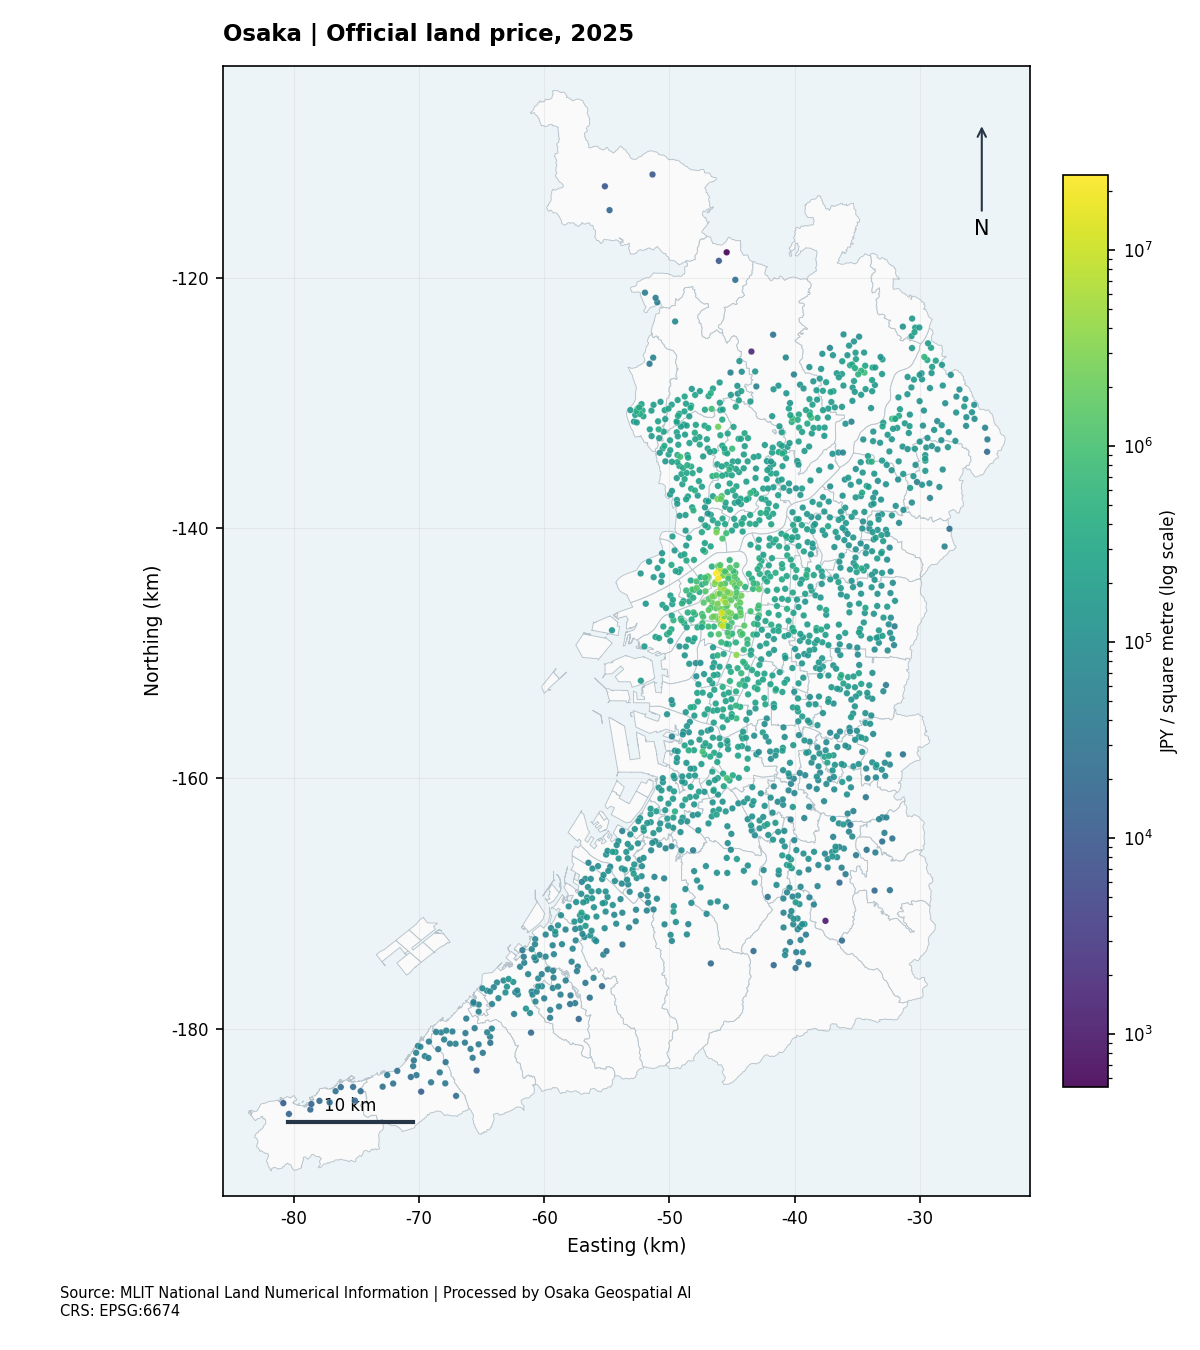

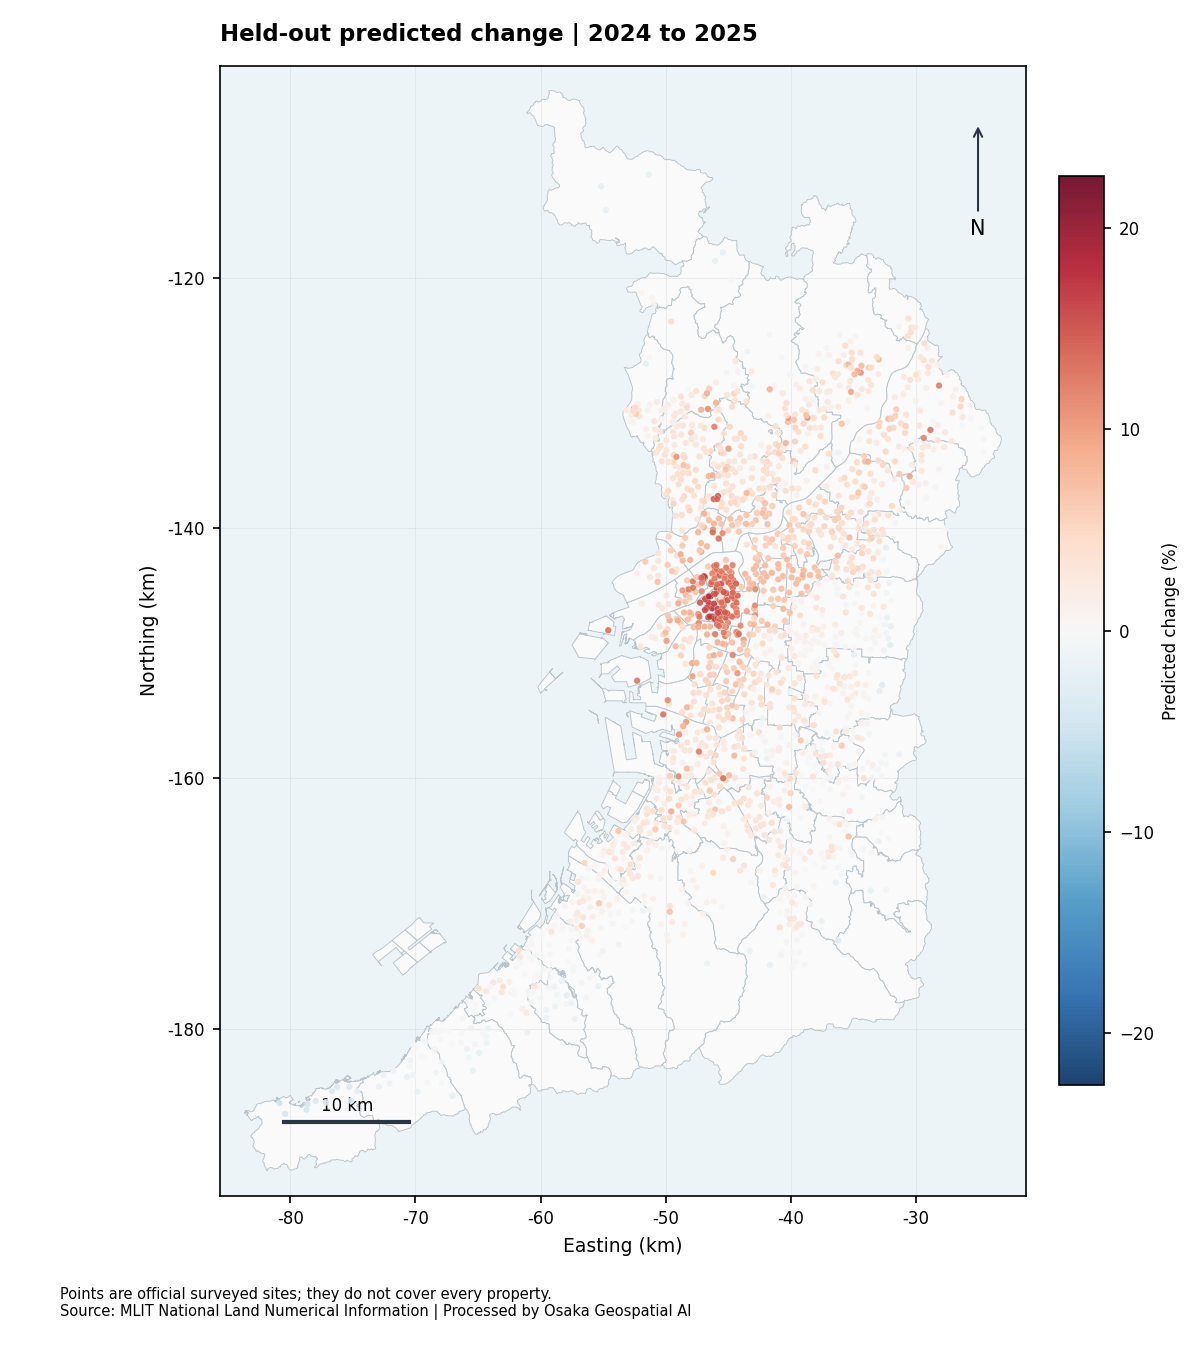

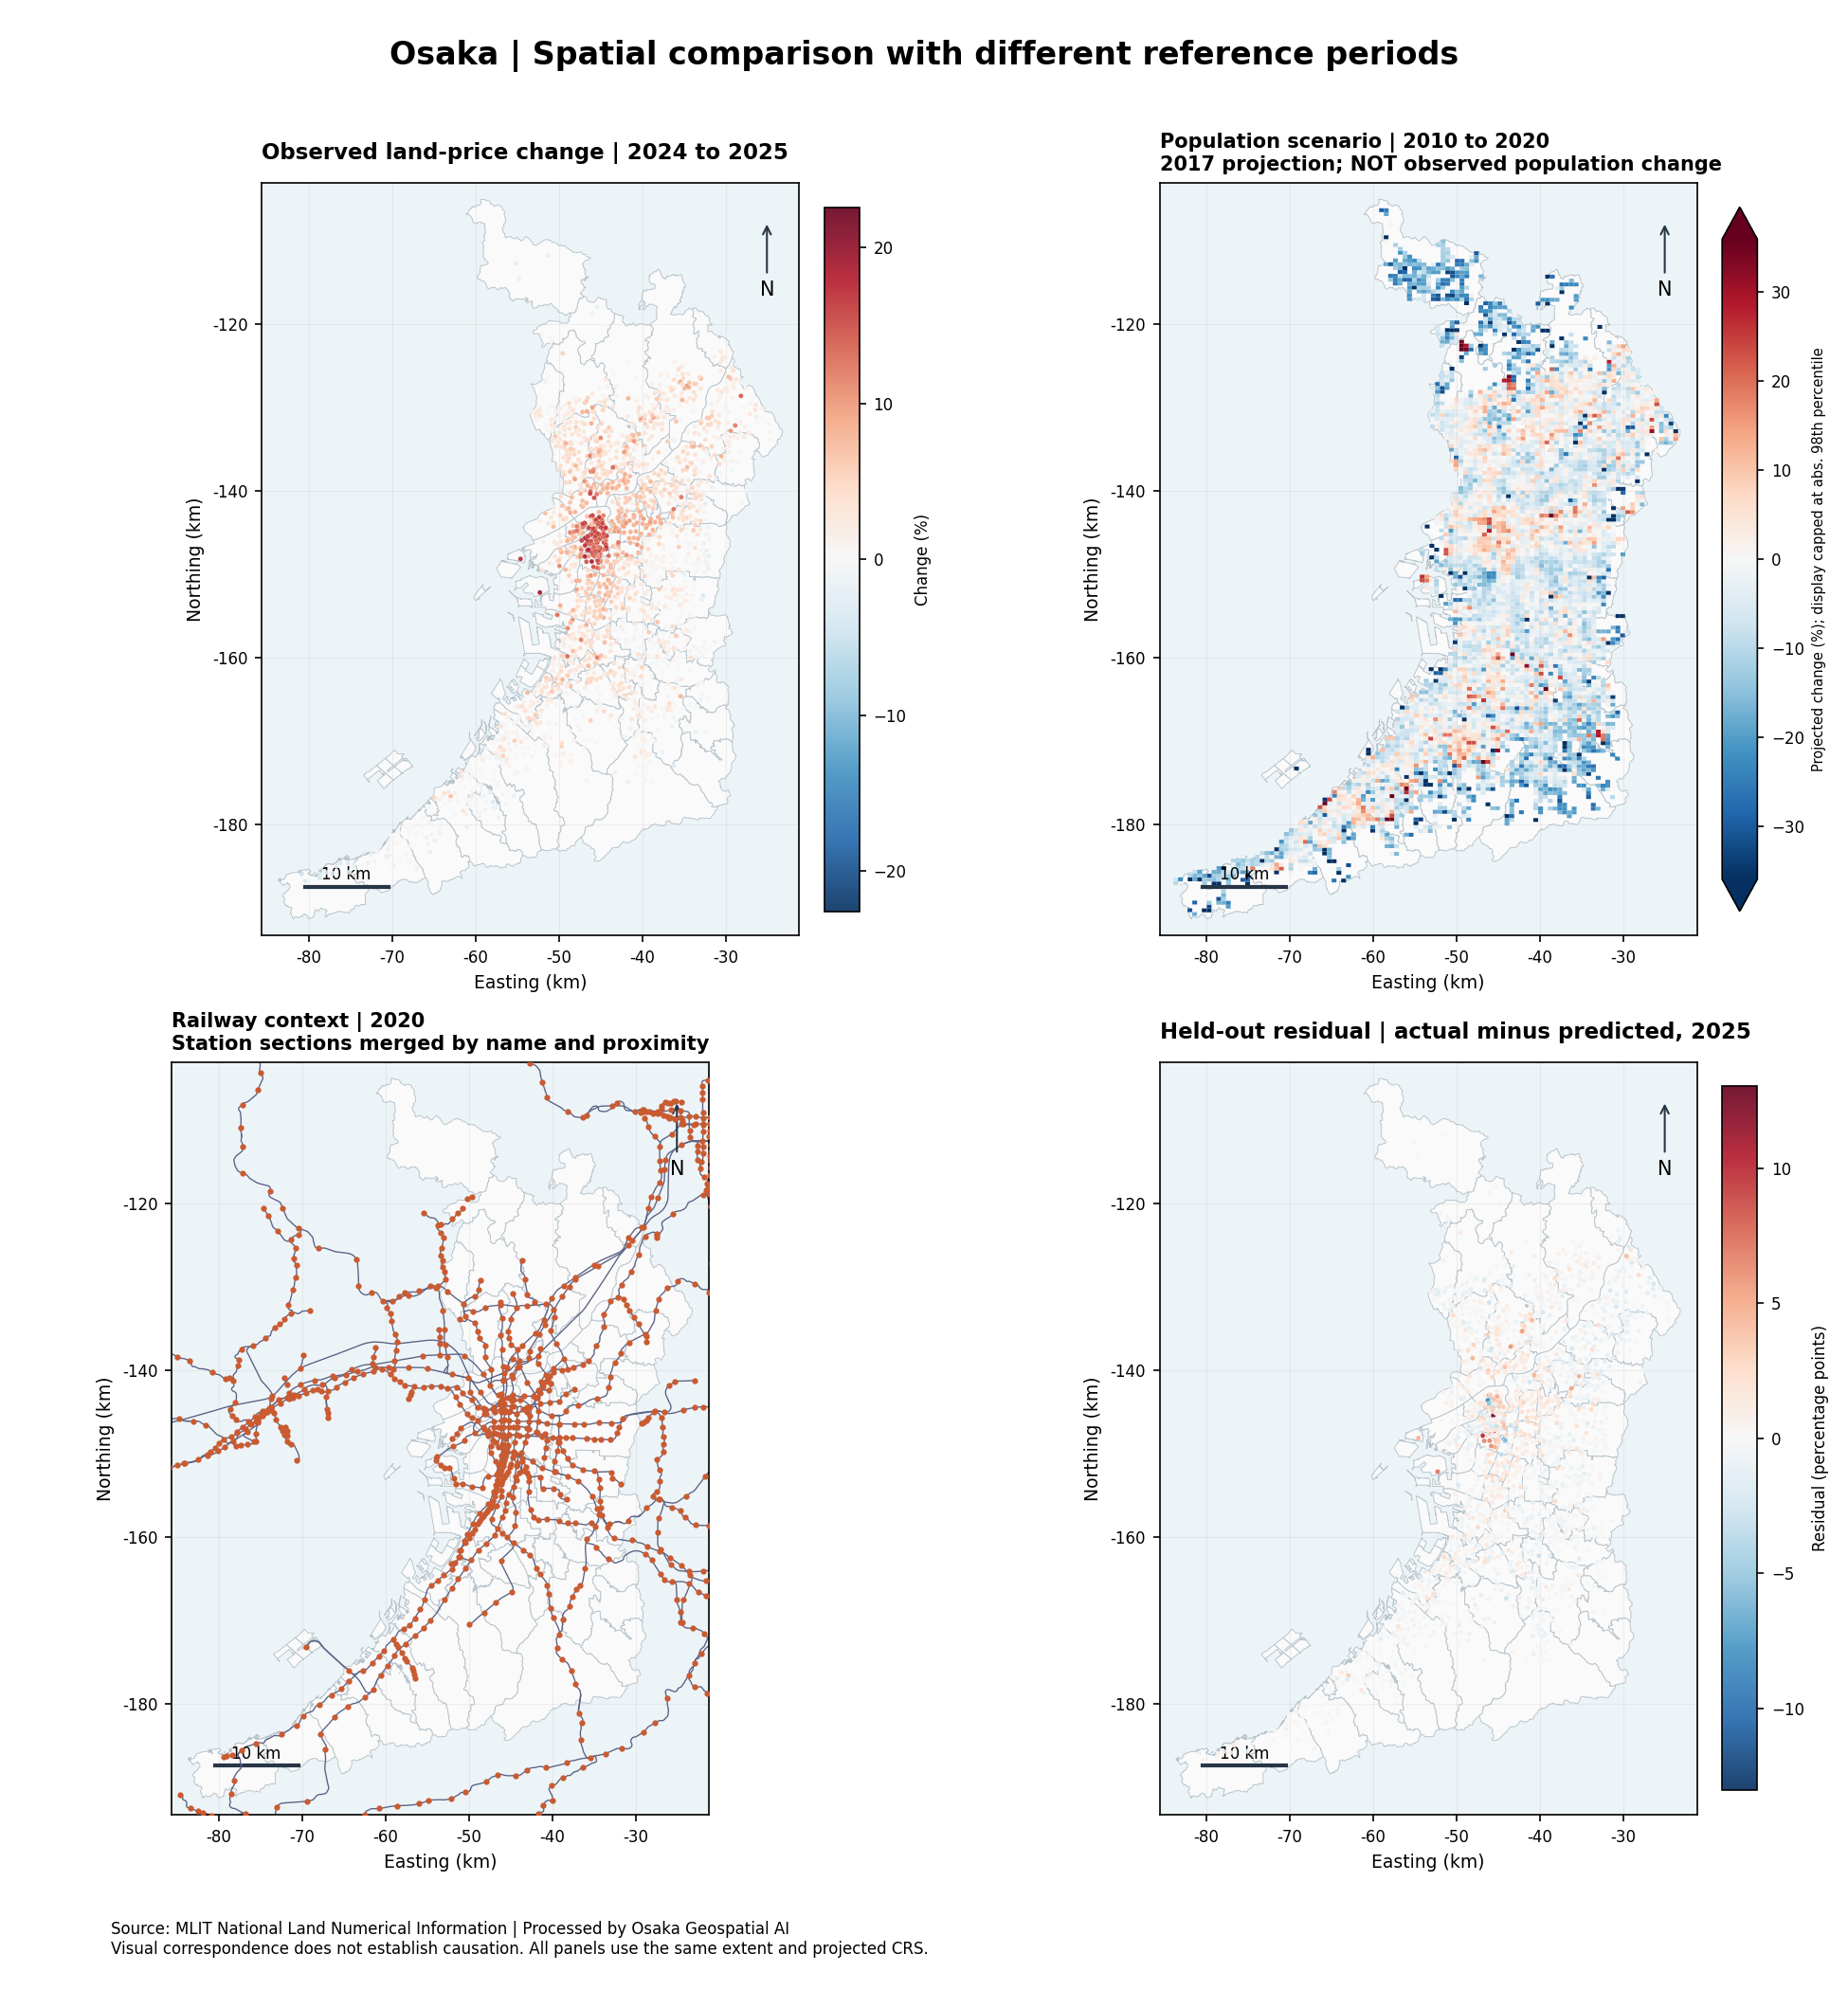

In [8]:
display(Image(filename=str(ROOT / "artifacts/figures/land_price_map.png"), width=650))
display(Image(filename=str(ROOT / "artifacts/figures/prediction_map.png"), width=650))
display(Image(filename=str(ROOT / "artifacts/figures/vlm_input_overview.png"), width=1000))

## 8. Model Metrics

モデル選択はvalidation MAEを用います。`mae_pp` と `rmse_pp` はパーセントポイントです。

In [9]:
display(metrics_table(ROOT))

,split,model,n,mae,rmse,r2,direction_accuracy,mae_pp,rmse_pp
0,validation,dummy,1698,0.026319,0.040770,-0.318010,0.760895,2.631861,4.076964
1,validation,ridge,1698,0.012684,0.020722,0.659496,0.813310,1.268360,2.072233
2,validation,random_forest,1698,0.012305,0.023243,0.571633,0.873380,1.230482,2.324263
3,validation,lightgbm,1698,0.012487,0.023041,0.579038,0.872203,1.248678,2.304086
4,test,dummy,1674,0.032579,0.047177,-0.323072,0.805854,3.257906,4.717651
5,test,ridge,1674,0.010955,0.015390,0.859197,0.851254,1.095477,1.539005
6,test,random_forest,1674,0.008765,0.013800,0.886794,0.909200,0.876548,1.379966
7,test,lightgbm,1674,0.009442,0.015088,0.864664,0.908005,0.944169,1.508831


## 9. Prediction Results

2025年テスト予測の抜粋です。別途、2026年予測を `forecast.parquet` に保存します。

In [10]:
display(prediction_preview(ROOT))

,row_id,site_id,municipality_code,municipality_name,year,target_year,longitude,latitude,land_price,prediction,actual,residual,predicted_land_price,prediction_role,model_name,fit_max_target_year
0,2024:27102-000-001,27102-000-001,27102,大阪都島,2024,2025,135.524715,34.725005,201000,0.034239,0.034826,0.000587,207882.100975,test,random_forest,2024
1,2024:27102-000-002,27102-000-002,27102,大阪都島,2024,2025,135.534446,34.713398,300000,0.075526,0.086667,0.011141,322657.663896,test,random_forest,2024
2,2024:27102-000-003,27102-000-003,27102,大阪都島,2024,2025,135.532872,34.709750,344000,0.075753,0.084302,0.008549,370059.021280,test,random_forest,2024
3,2024:27102-000-004,27102-000-004,27102,大阪都島,2024,2025,135.526044,34.700626,322000,0.070666,0.080745,0.010080,344754.399836,test,random_forest,2024
4,2024:27102-000-005,27102-000-005,27102,大阪都島,2024,2025,135.532954,34.704014,326000,0.069016,0.082822,0.013806,348499.351082,test,random_forest,2024
5,2024:27102-000-006,27102-000-006,27102,大阪都島,2024,2025,135.523384,34.704002,347000,0.075521,0.086455,0.010934,373205.850918,test,random_forest,2024
6,2024:27102-000-007,27102-000-007,27102,大阪都島,2024,2025,135.532540,34.715330,330000,0.060082,0.075758,0.015676,349826.928354,test,random_forest,2024
7,2024:27102-000-008,27102-000-008,27102,大阪都島,2024,2025,135.531068,34.707435,340000,0.073438,0.082353,0.008915,364968.994556,test,random_forest,2024
8,2024:27102-005-001,27102-005-001,27102,大阪都島,2024,2025,135.530518,34.696756,693000,0.081578,0.085137,0.003559,749533.416644,test,random_forest,2024
9,2024:27102-005-002,27102-005-002,27102,大阪都島,2024,2025,135.527086,34.693231,553000,0.082700,0.095841,0.013141,598732.906096,test,random_forest,2024


## 10. VLM Analysis

Hugging Face VLMによる視覚的観察です。正確な数値計算や因果推論として扱わず、`status` と `limitations` を確認してください。

In [11]:
display(JSON(filename=str(ROOT / "artifacts/vlm/map_analysis.json")))

<IPython.core.display.JSON object>

## 11. Final Report

検証済み `analysis.json` から作る定型説明に、Hugging Face LLMの生成説明を区別して追記します。

In [12]:
display(JSON(filename=str(ROOT / "artifacts/reports/report_generation.json")))
display(Markdown((ROOT / "artifacts/reports/report.md").read_text(encoding="utf-8")))

<IPython.core.display.JSON object>

# 大阪府 地価・地域変化分析

> 数値はPython/GIS/MLで算出したものです。この本文は検証済みJSONから生成した定型説明で、LLMの生成文章ではありません。

## 概要

大阪府の2025年地価公示を対象に、1,687地点を分析しました。地価公示は標準地の評価額であり、売買価格や全土地の相場そのものではありません。

## 現在確認できる傾向

**観測された事実:** 対象地点の公示価格の中央値は158,000円/㎡です。

**統計的分析結果:** 前年と接続できた1,674地点の平均変化率は3.70%でした。地点ごとの単純平均であり、府全体の土地面積に応じた平均ではありません。

## 地理的特徴

人口メッシュとの対応率は99.6%です。駅までの直線距離の中央値は596mでした。徒歩距離ではありません。

人口図は2010年を基準とする2017年作成の将来推計を示します。2020年・2025年に実測された人口とは区別してください。行政区域別集計・相関係数の詳細は `analysis.json` に収録しています。相関から地価変動の原因は確定できません。

## 地価予測

**MLによる予測:** 翌年の地価変化率を予測します。検証年のMAEで `random_forest` を選び、2025年の未学習データで評価しました。

| テスト指標 | 値 | 意味 |
|---|---:|---|
| MAE | 0.88 pp | 誤差の絶対値の平均 |
| RMSE | 1.38 pp | 大きな誤差を重く評価 |
| R² | 0.887 | 平均値予測と比べた適合の指標。負にもなる |
| 方向一致率 | 90.9% | 上昇・横ばい・下落の符号が一致した割合 |

`pp` はパーセントポイントです。実際が5%、予測が3%なら残差は+2 ppです。

別の `forecast.parquet` は2025年時点を想定した2026年予測です。実行日からの将来予測ではなく、この設定では実現値を評価していません。

## モデルが予測しにくかった地域

**統計的分析結果:** 対象地点のMAEが大きかった市区町村を示します。地点数の少ない地域の順位は不安定です。

| 市区町村 | 地点数 | MAE (pp) | 平均残差 (pp) |
|---|---:|---:|---:|
| 大阪浪速 | 12 | 4.46 | +4.30 |
| 大阪北 | 34 | 3.03 | +0.65 |
| 大阪中央 | 44 | 2.50 | +1.43 |
| 大阪天王寺 | 12 | 2.27 | -1.70 |
| 大阪東成 | 8 | 2.25 | +2.25 |

残差は実際の変化率から予測を引いた値です。正は過小予測、負は過大予測です。残差の集中だけで、その原因を特定することはできません。

## 地図から確認できる視覚的特徴

**VLMによる視覚的観察:** status=`completed`。

以下はVLMによる視覚的観察であり、数値的な検証や因果関係の証拠ではありません。

- Osaka Prefecture: Population change（モデル自己評価 0.95）
- Osaka Prefecture: Railway context（モデル自己評価 0.95）
- Osaka Prefecture: Held-out residual（モデル自己評価 0.95）

## 一般向けの説明

**解釈:** わかりやすく言うと、過去の地価と地域の特徴から翌年の変化を予測し、予測が外れた場所を地図で確認する仕組みです。予測の誤差と入力データの古さを踏まえて読む必要があります。

## 注意点・不確実性

- 地価公示の標準地が対象です。全土地の価格・実際の売買価格・府全体の面積加重平均を表しません。
- 人口の基準値は補正を含む2010年国勢調査ベース、2020・2025年値は2017年作成の将来推計です。現在人口や観測された人口増減ではありません。
- 鉄道は2020年、土地利用は2016年の固定スナップショットです。その後の新駅・土地利用変更を表しません。
- 補助データは設定の利用可能年より前へ使用しません。ただし当時配布された全ファイルの履歴保存はなく、厳密な過去時点データの再現性は保証しません。
- 前年番号・選定区分・用途・50m以内の位置を照合できる連続地点のみを教師ラベルにします。脱落・新設地点による選択バイアスがありえます。
- 時系列検証であり、未知の市町村への空間外挿検証ではありません。短い学習期間で、景気・政策・感染症などをモデル化していません。
- MAE/RMSEは変化率のfraction単位です。100倍するとパーセントポイントです。予測区間や確率校正は未実装です。
- VLMの観察は仮説です。因果関係や正確な数値を保証しません。異なる年次の地図を比較しています。
- 最新設定年からの予測は当該年時点の想定です。実行日の将来を意味せず、翌年の実現値として扱えません。
- 洪水データは未入力で、災害リスクは評価していません。欠測を安全と解釈できません。

## 出典

国土交通省の以下のデータを本PoCが編集・加工しています。モデル予測とレポートは国の公式見解ではありません。

- [land_price](https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-L01-2025.html) — CC BY 4.0 (2019 onwards)
- [population](https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-mesh500.html) — CC BY 4.0
- [railway](https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N02-v2_3.html) — Open data; source-specific terms and PDL 1.0
- [landuse](https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-L03-b.html) — Open data (2016); source-specific terms and PDL 1.0
- [boundary](https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N03-2024.html) — CC BY 4.0
